# **Predictors of math scores in 5th graders: A cross-sectional analysis**

## **About the project**

Objective: What are some predictors of math ability? This is a brief project done to showcase Python, SQL, and Power BI knowledge.

Data: ECLS-K:2011 Grade 5 public use version

Features used: Composite variables of 
1. Socioeconomic status (SES)
2. Executive functioning/behaviour (EF) report data from teachers
3. Math, reading, and science scores

## **Libraries used**

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')

## Getting the columns

Note that the files were read in as .sas files, so the indexing starts at 1. Subtract 1 from each index, and you get the corresponding Python index.

In [3]:
col_specs = [
    [0, 8],         # CHILDID
    [3758, 3760],   # X_CHSEX_R
    [3780, 3782],   # X_RACETH_R
    [1689, 1697],   # X9RSCALK5
    [1930, 1938],   # X9MSCALK5
    [2144, 2152],   # X9SSCALK5
    [4468, 4475],   # X9SESL_I
    [2906, 2912],   # X9TCHAPP
    [2980, 2986],   # X9TCHCON
    [3040, 3046],   # X9TCHPER
    [3108, 3114],   # X9TCHEXT
    [3182, 3188],   # X9TCHINT
    [3244, 3252],   # X9ATTMCQ
    [3308, 3316],   # X9INTMCQ
    [1472, 1474],   # X9RDGFLG
    [1713, 1715],   # X9MTHFLG
    [1952, 1954],   # X9SCIFLG
    [1482, 1483],   # X9RTOFLG
    [1723, 1724],   # X9MTOFLG
    [1961, 1962],   # X9STOFLG
    [3548, 3550],   # X9EXDIS
    [4782, 4784],   # X9ASMTST
]

# This is the ID key
# @1 CHILDID $8.

# Scaled score variables below
# @1690 X9RSCALK5 8.4 Reading 
# @1931 X9MSCALK5 8.4 Math 
# @2145 X9SSCALK5 8.4 Science 


# SES Composite variable
# @4469 X9SESL_I 7.4

# Teacher Report Scores Behavioural
# @2907 X9TCHAPP 6.4
# @2981 X9TCHCON 6.4
# @3041 X9TCHPER 6.2
# @3109 X9TCHEXT 6.4
# @3183 X9TCHINT 6.4
# @3245 X9ATTMCQ 8.4
# @3309 X9INTMCQ 8.4 

# Flags (used to filter out missing data and outlier scores; children with disabilities were not assessed, which is why they are excluded)

# Flag variables and their meanings:
# @1473  X9RDGFLG   float   0=no reading score, 1=score present, -9=not ascertained
# @1714  X9MTHFLG   float   0=no math score, 1=score present, -9=not ascertained
# @1953  X9SCIFLG   float   0=no science score, 1=score present, -9=not ascertained
# @1483  X9RTOFLG   float   0=not outlier, 1=outlier
# @1724  X9MTOFLG   float   0=not outlier, 1=outlier
# @1962  X9STOFLG   float   0=not outlier, 1=outlier
# @3549  X9EXDIS    float   -2=data suppressed (use as missing)
# @4783  X9ASMTST   float   1=assessed, 2=excluded due to disability, -9=not ascertained


The tuples are of the form (index, width) where the indexes are in the form **n - 1**, and the widths are the non-decimal portion of the second number in characters

In [4]:
names = [
          'CHILDID',
          'X_CHSEX_R', 'X_RACETH_R',
          'X9RSCALK5', 'X9MSCALK5', 'X9SSCALK5',
          'X9SESL_I',
          'X9TCHAPP', 'X9TCHCON', 'X9TCHPER', 'X9TCHEXT', 'X9TCHINT',
          'X9ATTMCQ', 'X9INTMCQ',
          'X9RDGFLG', 'X9MTHFLG', 'X9SCIFLG',
          'X9RTOFLG', 'X9MTOFLG', 'X9STOFLG',
          'X9EXDIS', 'X9ASMTST'
          ]

In [5]:
import io

with open('childK5p.dat') as f:
    first_lines = []
    for i, line in enumerate(f):
        if i % 27 == 0:
            first_lines.append(line)

df = pd.read_fwf(io.StringIO(''.join(first_lines)), colspecs=col_specs, names=names)
print(df.shape) #reads the relevant columns and their names

(18174, 22)


## Cleaning the data

In [6]:
print(df.shape)
print(df.dtypes)
print(df['X9ASMTST'].value_counts(dropna=False))

(18174, 22)
CHILDID         int64
X_CHSEX_R       int64
X_RACETH_R      int64
X9RSCALK5     float64
X9MSCALK5     float64
X9SSCALK5     float64
X9SESL_I      float64
X9TCHAPP      float64
X9TCHCON      float64
X9TCHPER      float64
X9TCHEXT      float64
X9TCHINT      float64
X9ATTMCQ      float64
X9INTMCQ      float64
X9RDGFLG      float64
X9MTHFLG      float64
X9SCIFLG      float64
X9RTOFLG      float64
X9MTOFLG      float64
X9STOFLG      float64
X9EXDIS         int64
X9ASMTST        int64
dtype: object
X9ASMTST
1    11445
2     6729
Name: count, dtype: int64


In [7]:
df.head()

,CHILDID,X_CHSEX_R,X_RACETH_R,X9RSCALK5,X9MSCALK5,X9SSCALK5,X9SESL_I,X9TCHAPP,X9TCHCON,X9TCHPER,X9TCHEXT,X9TCHINT,X9ATTMCQ,X9INTMCQ,X9RDGFLG,X9MTHFLG,X9SCIFLG,X9RTOFLG,X9MTOFLG,X9STOFLG,X9EXDIS,X9ASMTST
0,10000001,1,1,156.9485,135.7627,88.2353,-0.5030,1.5714,2.5,3.0,2.5,1.0,1.0,1.5714,1.0,1.0,1.0,0.0,0.0,0.0,-2,1
1,10000002,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2,2
2,10000003,1,3,NaN,NaN,NaN,1.8704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2,2
3,10000004,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2,2
4,10000005,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2,2


In [8]:
#Re-code values as missing; data is either not applicable, suppressed for public use, or not ascertained
df = df.replace([-1, -2, -9], np.nan)

#Includes data from children who were assessed
df = df[(df['X9ASMTST'] == 1)]

#Includes data from children who do not have any outlier scores
#Note: There are a very marginal number of outliers for each subject, so they likely wouldn't impact the results substantially given how large the dataset is
df = df[(df['X9MTOFLG'] != 1) | 
        (df['X9RTOFLG'] != 1) | 
        (df['X9STOFLG'] != 1)]

#Drops missing test scores
df = df.dropna(subset= ['X9RSCALK5','X9MSCALK5','X9SSCALK5'])
df.describe()


,CHILDID,X_CHSEX_R,X_RACETH_R,X9RSCALK5,X9MSCALK5,X9SSCALK5,X9SESL_I,X9TCHAPP,X9TCHCON,X9TCHPER,X9TCHEXT,X9TCHINT,X9ATTMCQ,X9INTMCQ,X9RDGFLG,X9MTHFLG,X9SCIFLG,X9RTOFLG,X9MTOFLG,X9STOFLG,X9EXDIS,X9ASMTST
count,1.141100e+04,11398.000000,11402.000000,11411.000000,11411.000000,11411.000000,9320.000000,10301.000000,10141.000000,10126.000000,10256.000000,10197.000000,10264.000000,10253.000000,11411.0,11411.0,11411.0,11411.000000,11411.000000,11411.000000,0.0,11411.0
mean,1.000907e+07,1.488682,2.396334,136.112526,119.710530,73.192270,-0.062705,3.124870,3.314959,3.141576,1.610112,1.567691,3.624072,3.818702,1.0,1.0,1.0,0.000088,0.001753,0.003768,NaN,1.0
std,5.253221e+03,0.499894,1.790344,15.674369,17.712826,13.000767,0.818322,0.702056,0.601099,0.651627,0.583755,0.521874,1.087602,0.807051,0.0,0.0,0.0,0.009361,0.041830,0.061273,NaN,0.0
min,1.000000e+07,1.000000,1.000000,72.267500,26.763500,25.187500,-2.735900,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,0.000000,0.000000,0.000000,NaN,1.0
25%,1.000454e+07,1.000000,1.000000,126.680000,110.177100,65.804600,-0.690400,2.571400,3.000000,2.600000,1.166700,1.250000,3.000000,3.285700,1.0,1.0,1.0,0.000000,0.000000,0.000000,NaN,1.0
50%,1.000902e+07,1.000000,2.000000,138.478500,122.646100,75.922600,-0.133600,3.142900,3.500000,3.200000,1.500000,1.500000,3.666700,3.857100,1.0,1.0,1.0,0.000000,0.000000,0.000000,NaN,1.0
75%,1.001366e+07,2.000000,3.000000,148.867700,133.187600,83.174800,0.555775,3.714300,3.750000,3.600000,2.000000,1.750000,4.666700,4.428600,1.0,1.0,1.0,0.000000,0.000000,0.000000,NaN,1.0
max,1.001818e+07,2.000000,8.000000,159.006200,148.038300,90.148300,2.272900,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,1.0,1.0,1.0,1.000000,1.000000,1.000000,NaN,1.0


In [9]:
df = df.drop(columns=['X9EXDIS'])

In [10]:
#Drop the flag columns since their use for filtering is done
df = df.drop(columns=['X9RDGFLG', 'X9MTHFLG', 'X9SCIFLG',
                       'X9RTOFLG', 'X9MTOFLG', 'X9STOFLG',
                       'X9ASMTST'])

Separate data frames are needed: One for SES only analysis, and the other for a full model.
The full model is n = 8050, while the SES only model is n = ~9300
Given that there were originally n=11411 rows, this is a pretty significant portion of the useable dataset.

## Setting up a database

In [11]:
df.head()

,CHILDID,X_CHSEX_R,X_RACETH_R,X9RSCALK5,X9MSCALK5,X9SSCALK5,X9SESL_I,X9TCHAPP,X9TCHCON,X9TCHPER,X9TCHEXT,X9TCHINT,X9ATTMCQ,X9INTMCQ
0,10000001,1.0,1.0,156.9485,135.7627,88.2353,-0.5030,1.5714,2.50,3.0,2.5,1.0,1.0000,1.5714
5,10000006,2.0,1.0,110.7324,78.0685,46.9979,-0.9112,2.2857,2.75,2.6,2.5,2.0,2.0000,2.7143
6,10000007,2.0,1.0,141.0794,119.2198,75.6502,-0.4848,4.0000,3.75,4.0,1.5,1.5,4.8333,4.8571
9,10000010,1.0,3.0,104.6828,92.9176,44.7353,NaN,3.2857,3.50,3.8,1.5,2.0,3.6667,3.5714
13,10000014,1.0,1.0,137.0652,125.8766,75.9290,-0.0834,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
#Connects to SQLite3
conn = sqlite3.connect('ecls_analysis.db')

In [13]:
#Splitting the dataframes into tables
demographics = df[['CHILDID','X_CHSEX_R','X_RACETH_R']].copy()
home = df[['CHILDID', 'X9SESL_I']].copy()
behaviour = df[['CHILDID','X9TCHAPP','X9TCHCON','X9TCHPER','X9TCHEXT','X9TCHINT','X9ATTMCQ', 'X9INTMCQ']].copy()
scores = df[['CHILDID', 'X9RSCALK5', 'X9MSCALK5', 'X9SSCALK5']].copy()

In [14]:
#Read the Pandas dataframes into SQLite3
demographics.to_sql('demographics', conn, if_exists='replace', index=False)
scores.to_sql('scores', conn, if_exists='replace', index=False)
behaviour.to_sql('behaviour', conn, if_exists='replace', index=False)
home.to_sql('home', conn, if_exists='replace', index=False)

11411

In [15]:
#Test code
pd.read_sql('SELECT * FROM scores LIMIT 5', conn)

,CHILDID,X9RSCALK5,X9MSCALK5,X9SSCALK5
0,10000001,156.9485,135.7627,88.2353
1,10000006,110.7324,78.0685,46.9979
2,10000007,141.0794,119.2198,75.6502
3,10000010,104.6828,92.9176,44.7353
4,10000014,137.0652,125.8766,75.9290


In [17]:
query = '''
SELECT 
    d.CHILDID,
    d.X_CHSEX_R,
    d.X_RACETH_R,
    h.X9SESL_I,
    sc.X9RSCALK5,
    sc.X9MSCALK5,
    sc.X9SSCALK5,
    cb.X9TCHAPP,
    cb.X9ATTMCQ,
    cb.X9INTMCQ
FROM demographics d
JOIN home h ON d.CHILDID = h.CHILDID
JOIN scores sc ON d.CHILDID = sc.CHILDID
JOIN behaviour cb ON d.CHILDID = cb.CHILDID
WHERE sc.X9MSCALK5 IS NOT NULL
'''

analysis_df = pd.read_sql(query, conn)


Below are some tests to check that the demographic tables haven't dropped values when reading to SQL

In [24]:
pd.read_sql('SELECT COUNT(*) FROM demographics', conn)


,COUNT(*)
0,11411


In [19]:
pd.read_sql('SELECT * FROM scores LIMIT 10', conn)

,CHILDID,X9RSCALK5,X9MSCALK5,X9SSCALK5
0,10000001,156.9485,135.7627,88.2353
1,10000006,110.7324,78.0685,46.9979
2,10000007,141.0794,119.2198,75.6502
3,10000010,104.6828,92.9176,44.7353
4,10000014,137.0652,125.8766,75.9290
5,10000016,104.5364,83.7544,43.5159
6,10000019,149.0134,144.9695,82.9222
7,10000020,147.8499,134.6042,84.8846
8,10000021,149.0563,146.9224,78.6855
9,10000022,157.2818,127.5906,89.3859


In [20]:
pd.read_sql('SELECT COUNT(*) FROM scores WHERE X9MSCALK5 IS NULL', conn)

,COUNT(*)
0,0


In [21]:
scores['X9MSCALK5'].isnull().sum()

np.int64(0)

In [23]:
print(len(demographics))

11411


Repeating for the other 3 tables below

In [25]:
pd.read_sql('SELECT COUNT(*) FROM home', conn)

,COUNT(*)
0,11411


In [26]:
len(home)

11411

In [27]:
pd.read_sql('SELECT * FROM home LIMIT 10', conn)

,CHILDID,X9SESL_I
0,10000001,-0.5030
1,10000006,-0.9112
2,10000007,-0.4848
3,10000010,NaN
4,10000014,-0.0834
5,10000016,-0.8674
6,10000019,1.6900
7,10000020,-0.4615
8,10000021,-0.1672
9,10000022,1.0477


In [31]:
df['X9SESL_I'].isnull().sum()

np.int64(2091)

In [28]:
pd.read_sql('SELECT COUNT(*) FROM home WHERE X9SESL_I IS NULL', conn)

,COUNT(*)
0,2091


In [32]:
pd.read_sql('SELECT COUNT(*) FROM behaviour', conn)

,COUNT(*)
0,11411


In [34]:
pd.read_sql('SELECT * FROM behaviour LIMIT 10', conn)

,CHILDID,X9TCHAPP,X9TCHCON,X9TCHPER,X9TCHEXT,X9TCHINT,X9ATTMCQ,X9INTMCQ
0,10000001,1.5714,2.50,3.0,2.5000,1.00,1.0000,1.5714
1,10000006,2.2857,2.75,2.6,2.5000,2.00,2.0000,2.7143
2,10000007,4.0000,3.75,4.0,1.5000,1.50,4.8333,4.8571
3,10000010,3.2857,3.50,3.8,1.5000,2.00,3.6667,3.5714
4,10000014,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10000016,2.2857,3.25,2.8,1.8333,2.25,3.3333,3.1429
6,10000019,3.7143,3.50,3.6,1.0000,1.75,4.8333,4.7143
7,10000020,4.0000,4.00,4.0,1.0000,1.00,5.0000,5.0000
8,10000021,4.0000,3.75,3.6,1.1667,1.25,5.0000,4.8333
9,10000022,4.0000,4.00,4.0,1.3333,1.25,5.0000,5.0000


In [35]:
pd.read_sql('SELECT COUNT(*) FROM behaviour WHERE X9ATTMCQ IS NULL', conn)

,COUNT(*)
0,1147


In [36]:
df['X9ATTMCQ'].isnull().sum()

np.int64(1147)

The counts match for the df and their sql equivalents. The database here isn't really necessary because it's so simple (mainly just showing I can use a SQL query).

## Analysis

This is where things get fun :D
Below is a full correlation matrix. The 1s show up on the diagonal of the matrix because each item correlates perfectly with itself.

In [37]:
df.corr()

,CHILDID,X_CHSEX_R,X_RACETH_R,X9RSCALK5,X9MSCALK5,X9SSCALK5,X9SESL_I,X9TCHAPP,X9TCHCON,X9TCHPER,X9TCHEXT,X9TCHINT,X9ATTMCQ,X9INTMCQ
CHILDID,1.000000,-0.003681,-0.006238,0.003380,0.007664,0.006596,-0.008266,-0.002155,-0.003804,0.002442,0.010631,0.002679,-0.003059,-0.005701
X_CHSEX_R,-0.003681,1.000000,0.017132,0.062281,-0.039431,-0.030897,0.003078,0.294312,0.219970,0.254520,-0.263065,-0.018421,0.285714,0.323195
X_RACETH_R,-0.006238,0.017132,1.000000,-0.047309,-0.055610,-0.076973,-0.139669,0.019094,0.011961,0.001688,-0.038167,-0.015322,0.028628,0.018135
X9RSCALK5,0.003380,0.062281,-0.047309,1.000000,0.754614,0.761448,0.428984,0.380470,0.224879,0.220490,-0.191643,-0.185600,0.383932,0.282724
X9MSCALK5,0.007664,-0.039431,-0.055610,0.754614,1.000000,0.760596,0.435322,0.396898,0.229166,0.216039,-0.183230,-0.231594,0.393779,0.282365
X9SSCALK5,0.006596,-0.030897,-0.076973,0.761448,0.760596,1.000000,0.426761,0.324228,0.199301,0.192925,-0.157117,-0.160379,0.330082,0.233300
X9SESL_I,-0.008266,0.003078,-0.139669,0.428984,0.435322,0.426761,1.000000,0.199541,0.150361,0.154185,-0.100918,-0.109061,0.184559,0.151379
X9TCHAPP,-0.002155,0.294312,0.019094,0.380470,0.396898,0.324228,0.199541,1.000000,0.714195,0.724838,-0.612430,-0.402514,0.829284,0.756538
X9TCHCON,-0.003804,0.219970,0.011961,0.224879,0.229166,0.199301,0.150361,0.714195,1.000000,0.803201,-0.724738,-0.335413,0.606061,0.680958
X9TCHPER,0.002442,0.254520,0.001688,0.220490,0.216039,0.192925,0.154185,0.724838,0.803201,1.000000,-0.613319,-0.369202,0.587383,0.624319


X9(R/M/S)SCALK5 represent the reading, math, and science scores.

**Notable correlations** (not all of these are relevant to the question, but I will probably come back to them for further analysis later)

1. Math, reading, and science correlate moderately strongly (~.75 to ~.76 correlations)
2. The socioeconomic composite measure (X9SESL_I) has a moderate positive correlation with each of the subject scaled scores, indicating that parental education and household income may have some influence on scores
3. Small negative correlation between internalizing behaviours (X9TCHINT) and math scaled score (X9MSCALK5); this could indicative of math anxiety being a factor (though internalizing behaviours aren't always anxiety)
4. Small-Moderate positive correlation between attention (X9ATTMCQ) and each subject score, but it is most pronounced in math and reading, compared to science; Paying more attention in class would explain why scores would be higher, since information that is not attended to isn't processed effectively
5. Small positive correlation between inhibitory control (X9INTMCQ) and subject scores; better ability to suppress behaviours could extend to better ability to resist drifting attention, and is supported by a moderate-strong positive correlation with attention (X9ATTMCQ)

<Axes: xlabel='X_CHSEX_R', ylabel='X9MSCALK5'>

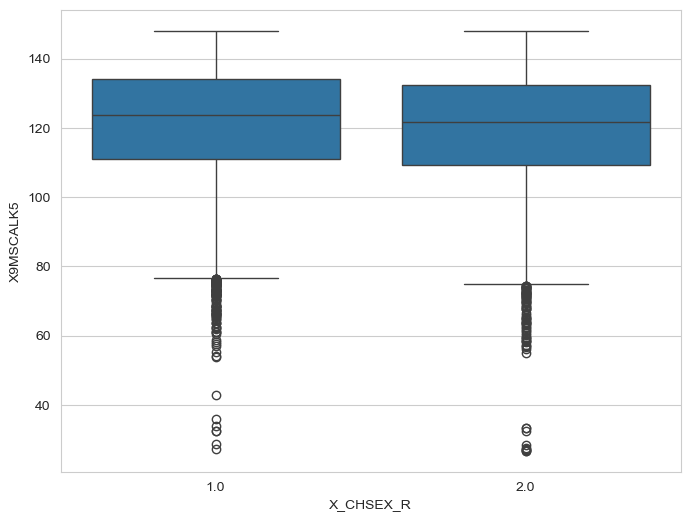

In [38]:
plt.figure(figsize=(8,6))
sns.boxplot(x='X_CHSEX_R',y='X9MSCALK5', data=df)

Figure 1: The boxplot shows that there were minimal differences between male and female math scores

<Axes: xlabel='X9SESL_I', ylabel='X9MSCALK5'>

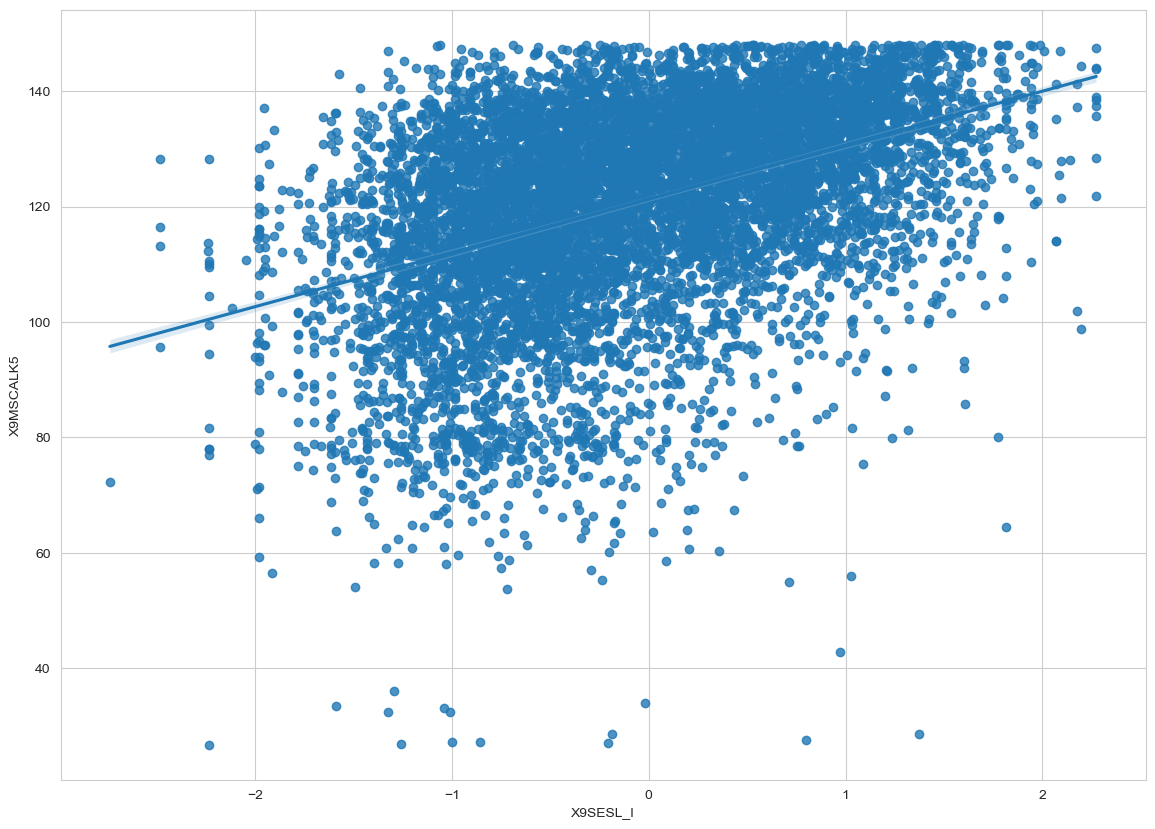

In [48]:
plt.figure(figsize=(14,10))
sns.regplot(x='X9SESL_I',y='X9MSCALK5', data=df)

In [50]:
clean = analysis_df[['X9SESL_I', 'X9MSCALK5']].dropna()
r, p_value = stats.pearsonr(clean['X9SESL_I'], clean['X9MSCALK5'])
print(f'r = {r:.4f}, p = {p_value}')

r = 0.4353, p = 0.0


SES and 5th-grade math achievement showed a moderate positive correlation (r = .44, p < .001), indicating that higher household socioeconomic status is associated with higher math scores. SES accounts for approximately 19% of the variance in math achievement.

In [ ]:
#Closes the SQLite connection
conn.close()